# ZOOP Megastore — 1ª Etapa
## Exploração e limpeza dos dados com Pandas

**Pergunta-chave:** Como foi nosso desempenho de vendas no primeiro trimestre e quais são as categorias de maior destaque?

Este notebook realiza:
1. Carregamento do `vendas.csv`
2. Diagnóstico de dados ausentes e duplicados
3. Limpeza e conversão dos tipos
4. Cálculo do faturamento
5. Análise mensal
6. Análise por categoria
7. Visualizações com Matplotlib


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Exibição de até 100 linhas nas tabelas
pd.set_option("display.max_rows", 100)

# Carregamento
vendas = pd.read_csv("../data/raw/vendas.csv")

print(f"Linhas: {vendas.shape[0]}")
print(f"Colunas: {vendas.shape[1]}")

display(vendas.head())


Linhas: 120
Colunas: 8


,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1


## 1. Diagnóstico inicial

In [3]:
print("Informações do DataFrame:")
vendas.info()

print("\nValores ausentes por coluna:")
display(vendas.isna().sum())

print(f"\nTotal de linhas duplicadas: {vendas.duplicated().sum()}")


Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     120 non-null    int64  
 1   data_venda   120 non-null    str    
 2   id_cliente   120 non-null    int64  
 3   id_produto   120 non-null    int64  
 4   produto      120 non-null    str    
 5   categoria    120 non-null    str    
 6   valor_venda  120 non-null    float64
 7   quantidade   120 non-null    int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 7.6 KB

Valores ausentes por coluna:


id_venda       0
data_venda     0
id_cliente     0
id_produto     0
produto        0
categoria      0
valor_venda    0
quantidade     0
dtype: int64


Total de linhas duplicadas: 0


### Estratégia de limpeza

Para o cálculo do faturamento, `valor_venda`, `quantidade` e `data_venda` são informações essenciais.

Caso existam valores ausentes nessas colunas, não é seguro preencher automaticamente com média ou mediana, pois isso poderia criar um faturamento artificial. Neste exercício, portanto, os registros sem esses dados serão removidos.

Duplicidades também serão removidas.


In [4]:
# Conversão dos tipos
vendas["data_venda"] = pd.to_datetime(
    vendas["data_venda"],
    errors="coerce"
)

vendas["valor_venda"] = pd.to_numeric(
    vendas["valor_venda"],
    errors="coerce"
)

vendas["quantidade"] = pd.to_numeric(
    vendas["quantidade"],
    errors="coerce"
)

# Quantidade de registros antes da limpeza
linhas_antes = len(vendas)

# Remoção de registros sem dados essenciais
vendas = vendas.dropna(
    subset=["data_venda", "valor_venda", "quantidade"]
)

# Remoção de duplicados
vendas = vendas.drop_duplicates()

linhas_depois = len(vendas)

print(f"Linhas antes da limpeza: {linhas_antes}")
print(f"Linhas depois da limpeza: {linhas_depois}")
print(f"Linhas removidas: {linhas_antes - linhas_depois}")


Linhas antes da limpeza: 120
Linhas depois da limpeza: 120
Linhas removidas: 0


## 2. Cálculo do faturamento

In [5]:
vendas["faturamento"] = (
    vendas["valor_venda"] * vendas["quantidade"]
)

faturamento_total = vendas["faturamento"].sum()

print(f"Faturamento total: R$ {faturamento_total:,.2f}")

display(vendas.head())


Faturamento total: R$ 810,828.88


,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89


## 3. Faturamento por mês

In [6]:
vendas["mes"] = vendas["data_venda"].dt.to_period("M")

faturamento_mensal = (
    vendas
    .groupby("mes")["faturamento"]
    .sum()
    .sort_index()
)

display(
    faturamento_mensal.to_frame("faturamento")
)


,faturamento
mes,
2023-01,234634.61
2023-02,282351.34
2023-03,293842.93


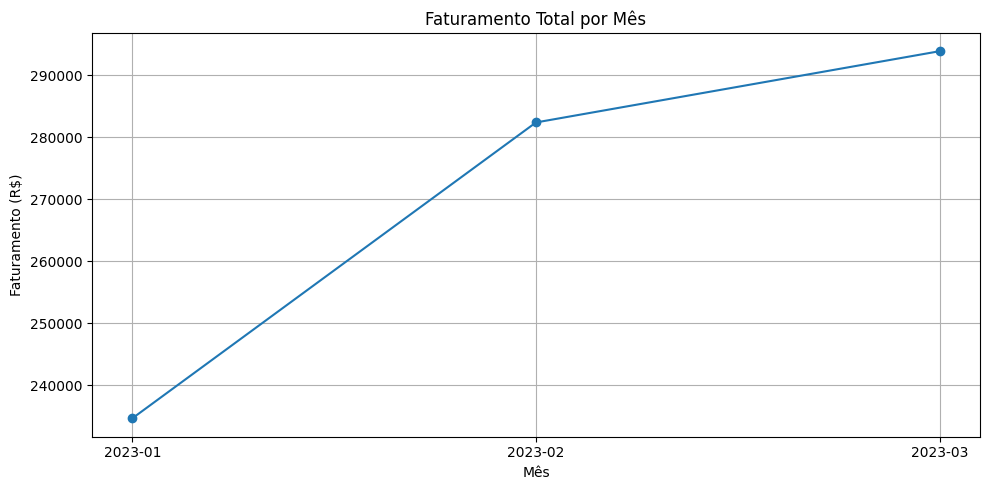

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index.astype(str),
    faturamento_mensal.values,
    marker="o"
)

plt.title("Faturamento Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.grid(True)

plt.tight_layout()
plt.show()


## 4. Faturamento por categoria

In [8]:
faturamento_categoria = (
    vendas
    .groupby("categoria")["faturamento"]
    .sum()
    .sort_values(ascending=False)
)

display(
    faturamento_categoria.to_frame("faturamento")
)

# Participação percentual
participacao_categoria = (
    faturamento_categoria
    / faturamento_categoria.sum()
    * 100
)

resumo_categoria = pd.DataFrame({
    "faturamento": faturamento_categoria,
    "participacao_%": participacao_categoria
})

display(resumo_categoria)


,faturamento
categoria,
Periféricos,307921.82
Livros,140285.75
Eletrônicos,124973.54
Decoração,109156.43
Colecionáveis,55658.46
Componentes,35468.07
Áudio,29281.47
Móveis,8083.34


,faturamento,participacao_%
categoria,,
Periféricos,307921.82,37.976178
Livros,140285.75,17.301524
Eletrônicos,124973.54,15.413060
Decoração,109156.43,13.462326
Colecionáveis,55658.46,6.864390
Componentes,35468.07,4.374298
Áudio,29281.47,3.611301
Móveis,8083.34,0.996923


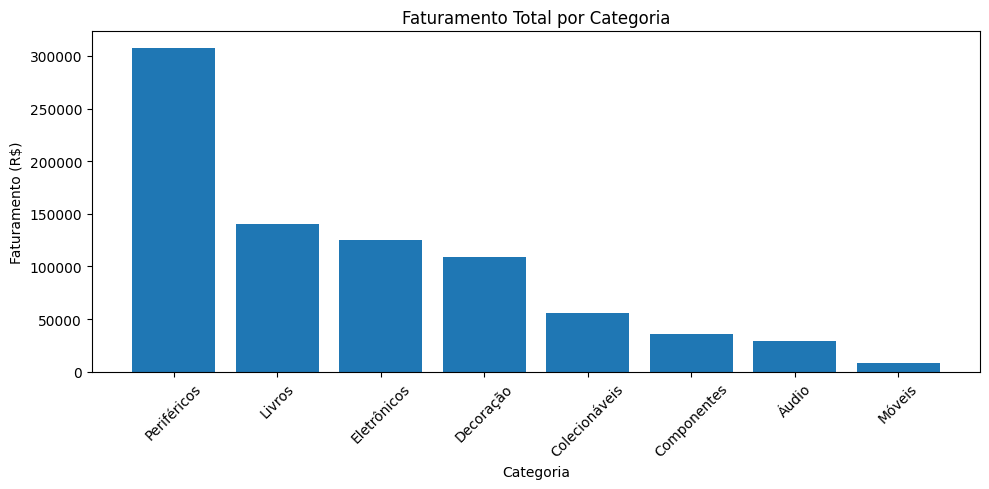

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    faturamento_categoria.index,
    faturamento_categoria.values
)

plt.title("Faturamento Total por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 5. Indicadores finais

Vamos consolidar os principais indicadores para facilitar a interpretação.


In [10]:
numero_vendas = vendas["id_venda"].nunique()
unidades_vendidas = vendas["quantidade"].sum()
clientes_unicos = vendas["id_cliente"].nunique()
ticket_medio = faturamento_total / numero_vendas

print(f"Faturamento total:     R$ {faturamento_total:,.2f}")
print(f"Número de vendas:      {numero_vendas}")
print(f"Unidades vendidas:     {unidades_vendidas}")
print(f"Clientes únicos:       {clientes_unicos}")
print(f"Ticket médio:          R$ {ticket_medio:,.2f}")

categoria_lider = faturamento_categoria.idxmax()
valor_categoria_lider = faturamento_categoria.max()
participacao_lider = (
    valor_categoria_lider / faturamento_total * 100
)

print(f"\nCategoria líder:       {categoria_lider}")
print(f"Faturamento da líder:  R$ {valor_categoria_lider:,.2f}")
print(f"Participação:          {participacao_lider:.2f}%")


Faturamento total:     R$ 810,828.88
Número de vendas:      120
Unidades vendidas:     291
Clientes únicos:       45
Ticket médio:          R$ 6,756.91

Categoria líder:       Periféricos
Faturamento da líder:  R$ 307,921.82
Participação:          37.98%


# Salvando arquivos

In [14]:
from pathlib import Path

PASTA_DOWNLOADS = Path.home() / "Downloads"

caminho_partidas = PASTA_DOWNLOADS / "vendas_tratado.csv"

vendas.to_csv(caminho_partidas, index=False, encoding='utf-8')
